In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
save_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/tasks")
save_dir.mkdir(parents=True, exist_ok=True)

In [5]:
def collect_wandb_run_dirs(
        sweep_dir,
        type_of_run: Literal['run', 'offline-run']='run'
    ):
    wandb_run_dirs = []
    for d in os.listdir(sweep_dir / "wandb"):
        if type_of_run in d:
            # print(d)
            wandb_run_dirs.append(sweep_dir / "wandb" / d)
    return wandb_run_dirs

In [6]:
def build_sweep_test_results_df(
        wandb_run_dirs,
        split: Literal['1-test-patch', '3-test-patch']='3-test-patch'
    ):
    wandb_run_dir_dfs = []
    for wandb_run_dir in wandb_run_dirs:
        if isinstance(wandb_run_dir, str):
            cfg = f"{wandb_run_dir}/files/user_specified_config.yaml"
            test_res_file = f"{wandb_run_dir}/files/results/test_metrics.csv"
        else:
            cfg = wandb_run_dir/"files"/"user_specified_config.yaml"
            test_res_file = wandb_run_dir/"files"/"results"/"test_metrics.csv"
        with open(cfg, 'r') as f:
            cfg = yaml.safe_load(f)
        test_results_df = pd.read_csv(test_res_file)
        
        test_results_df['dataset'] = cfg['dataset']['dataset_name']
        test_results_df['num_train_sections'] = len(cfg['dataset']['train_transform_params']['train_batches'])
        test_results_df['model'] = cfg['model']['model_name']
        test_results_df['seed'] = cfg['experiment']['seed']
        test_results_df['split'] = split

        wandb_run_dir_dfs.append(test_results_df)
        
    sweep_results = pd.concat(
        objs=wandb_run_dir_dfs,
        ignore_index=True
    )

    return sweep_results

In [7]:
def build_clean_sweep_results_df(
        df: pd.DataFrame,
        metrics: List[str] = [
            "pearson_1hop_nbr",
            "pearson_gene_wise_1hop_nbr",
            "mmd_1hop_nbr",
            "mmd_pca_1hop_nbr",
        ]
    ):
    # --- Step 1: groupby and transpose ---
    df_long = df.melt(
        id_vars=["dataset", "seed", "model", "split", "epoch", "num_train_sections"], 
        var_name="metric", 
        value_name="value"
    )
    
    # --- Step 2: strip mode from metric name ---
    df_long["mode"] = df_long["metric"].str.extract(r"^(train|val|test)")
    df_long["metric"] = df_long["metric"].str.replace(r"^(train|val|test)_", "", regex=True)
    df_long = df_long[df_long['metric'].isin(metrics)]

    # --- Step 3: pretty names for metric ---
    metric_rename = {
        "pearson_1hop_nbr": "PC1",
        "pearson_gene_wise_1hop_nbr": "PG1",
        "pearson_cell_wise": "PC0",
        "mmd_1hop_nbr": "MMDC1",
        "mmd_pca_1hop_nbr": "MMD-PCA-C-1hop",
    }
    df_long["metric"] = df_long["metric"].map(metric_rename)

    # --- Step 4: pretty names for model ---
    model_rename = {
        "VQNiche": "SQUINT",
        "WFM": "WFM",
    }
    df_long["model"] = df_long["model"].map(model_rename)
    
    # --- Step 5: pretty names for dataset ---
    dataset_rename = {
        "xhs1000-39b_1p": "Skin (Human)",
        "mmb0-4b_1p": "Brain (Mouse)",
        "xhk1020-CV1-CV2-5b_1p": "Kidney (Human)",
    }
    df_long["dataset"] = df_long["dataset"].map(dataset_rename)
    
    # --- Step 6: pretty names for split ---
    split_rename = {
        "1-test-patch": "1 Patch",
        "3-test-patch": "3 Patches",
    }
    df_long["split"] = df_long["split"].map(split_rename)
    
    # --- Step 7: round to 4 decimals ---
    df_long['value'] = df_long['value'].round(4)
    
    df_long = df_long.drop_duplicates()
    
    return df_long

In [69]:
def score_vs_num_train_sections_by_metric(
        df,
        width=4,
        height=4,
        legend_order=['PC0', 'PG1', 'PC1', 'MMDC1'],
        save_dir=None,
    ):
    s = 14
    plt.rcParams.update({
        "font.size": s,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.weight": 5,
    })

    # fixed palette per metric    
    palette = {
        "MMDC1": "pink",
        "PC0": "#8e44ad",  # dark purple
        "PC1": "#a569bd",  # lighter purple
        "PG1": "#bb8fce",  # another shade if PG1 is also included
    }

    markers = {
        "MMDC1": "o",   # circle
        "PC0": "s",     # square
        "PC1": "D",     # diamond
        "PG1": "^",     # triangle
    }

    fig, ax = plt.subplots(
        1, 1,
        figsize=(width, height),
        sharey=True,
    )

    sns.lineplot(
        data=df,
        x="num_train_sections",
        y="value",
        hue="metric",
        hue_order=legend_order,
        style="metric",
        markers=markers,
        dashes=False,
        palette=palette,
        ax=ax,
        markersize=10
    )

    ax.set_xlabel("Number of Training Sections")
    ax.set_ylabel("Imputation Score")
    ax.set_ylim(0.0, 1.0)
    ax.set_xticks(ax.get_xticks()[1:-1])
    if ax.legend_ is not None:
        ax.legend_.remove()

    # --- build and reorder legend ---
    handles, labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))
    labels = list(legend_order)
    handles = [label_to_handle[l] for l in labels if l in label_to_handle]

    # place legend at the top
    fig.legend(
        handles, labels,
        title="Imputation Metric",
        fontsize=s,
        title_fontsize=s,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.85),
        # bbox_to_anchor=(0.5, -0.15), # bottom
        ncol=len(labels)/2,
        frameon=False,
    )
    # leave top space for split headers and bottom space for legend
    plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])
    
    if save_dir is not None:
        fname = save_dir / f"metrics_vs_num_train_sections_{df['split'].unique().tolist()[0]}.pdf"
        plt.savefig(fname, bbox_inches="tight")
    else:
        plt.show()


# 3 Region Test

In [34]:
df_datasets = []
metrics = [
    "pearson_1hop_nbr",
    "pearson_cell_wise",
    "pearson_gene_wise_1hop_nbr",
    "mmd_1hop_nbr",
    # "mmd_pca_1hop_nbr"
]

## Dataset: xhs1000-39b_1p-oriented-3

In [35]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250917-210622")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0250,0.410830,0.738857,0.105257,0.295920,0.107091,0.004112,19,xhs1000-39b_1p,2,VQNiche,0,3-test-patch
1,0.0196,0.379068,0.666443,0.083465,0.245880,0.114131,0.003866,19,xhs1000-39b_1p,2,VQNiche,1,3-test-patch
2,0.0208,0.389794,0.683567,0.092848,0.259767,0.113180,0.004081,18,xhs1000-39b_1p,2,VQNiche,2,3-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,3 Patches,19,2,PC0,0.4108,test
5,Skin (Human),1,SQUINT,3 Patches,19,2,PC0,0.3791,test
6,Skin (Human),2,SQUINT,3 Patches,18,2,PC0,0.3898,test


## Dataset: xhs1000-39b_1p-oriented-4

In [36]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 12]/spatial_n_neighs_8/seed/20250918-014612")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0144,0.363660,0.645612,0.082956,0.219448,0.133385,0.006633,9,xhs1000-39b_1p,3,VQNiche,1,3-test-patch
1,0.0164,0.395069,0.688294,0.082912,0.222475,0.110428,0.004393,9,xhs1000-39b_1p,3,VQNiche,0,3-test-patch
2,0.0144,0.411989,0.734285,0.103868,0.272658,0.086577,0.003828,9,xhs1000-39b_1p,3,VQNiche,2,3-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),1,SQUINT,3 Patches,9,3,PC0,0.3637,test
5,Skin (Human),0,SQUINT,3 Patches,9,3,PC0,0.3951,test
6,Skin (Human),2,SQUINT,3 Patches,9,3,PC0,0.4120,test


## Dataset: xhs1000-39b_1p-oriented-5

In [37]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 12]/spatial_n_neighs_8/seed/20250918-020433")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0126,0.394085,0.697063,0.098718,0.253204,0.122721,0.007350,9,xhs1000-39b_1p,4,VQNiche,0,3-test-patch
1,0.0104,0.407330,0.727159,0.097494,0.251262,0.105872,0.003887,9,xhs1000-39b_1p,4,VQNiche,2,3-test-patch
2,0.0104,0.407330,0.727159,0.097494,0.251262,0.105872,0.003887,9,xhs1000-39b_1p,4,VQNiche,2,3-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,3 Patches,9,4,PC0,0.3941,test
5,Skin (Human),2,SQUINT,3 Patches,9,4,PC0,0.4073,test
7,Skin (Human),1,SQUINT,3 Patches,9,4,PC0,0.3867,test


## Dataset: xhs1000-39b_1p-oriented-6

In [38]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250917-210622")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['num_train_sections'] = 5
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0250,0.410830,0.738857,0.105257,0.295920,0.107091,0.004112,19,xhs1000-39b_1p,2,VQNiche,0,3-test-patch
1,0.0196,0.379068,0.666443,0.083465,0.245880,0.114131,0.003866,19,xhs1000-39b_1p,2,VQNiche,1,3-test-patch
2,0.0208,0.389794,0.683567,0.092848,0.259767,0.113180,0.004081,18,xhs1000-39b_1p,2,VQNiche,2,3-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,3 Patches,19,5,PC0,0.4108,test
5,Skin (Human),1,SQUINT,3 Patches,19,5,PC0,0.3791,test
6,Skin (Human),2,SQUINT,3 Patches,18,5,PC0,0.3898,test


## Dataset: xhs1000-39b_1p-oriented-7

In [39]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250917-210622")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='3-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['num_train_sections'] = 6
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0250,0.410830,0.738857,0.105257,0.295920,0.107091,0.004112,19,xhs1000-39b_1p,2,VQNiche,0,3-test-patch
1,0.0196,0.379068,0.666443,0.083465,0.245880,0.114131,0.003866,19,xhs1000-39b_1p,2,VQNiche,1,3-test-patch
2,0.0208,0.389794,0.683567,0.092848,0.259767,0.113180,0.004081,18,xhs1000-39b_1p,2,VQNiche,2,3-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,3 Patches,19,6,PC0,0.4108,test
5,Skin (Human),1,SQUINT,3 Patches,19,6,PC0,0.3791,test
6,Skin (Human),2,SQUINT,3 Patches,18,6,PC0,0.3898,test


## Figure

In [47]:
df_long = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
df_long['num_train_sections'] = df_long['num_train_sections'].astype('category')
display(df_long.head(3))

,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
0,Skin (Human),0,SQUINT,3 Patches,19,2,PC0,0.4108,test
1,Skin (Human),1,SQUINT,3 Patches,19,2,PC0,0.3791,test
2,Skin (Human),2,SQUINT,3 Patches,18,2,PC0,0.3898,test


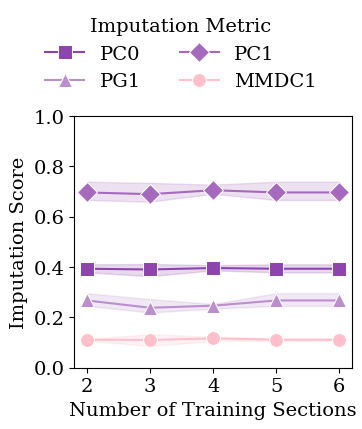

In [70]:
score_vs_num_train_sections_by_metric(
    df_long,
    save_dir=save_dir,
    width=4,
    height=4,
)

In [61]:
display(df_long)

,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
0,Skin (Human),0,SQUINT,3 Patches,19,2,PC0,0.4108,test
1,Skin (Human),1,SQUINT,3 Patches,19,2,PC0,0.3791,test
2,Skin (Human),2,SQUINT,3 Patches,18,2,PC0,0.3898,test
3,Skin (Human),0,SQUINT,3 Patches,19,2,PC1,0.7389,test
4,Skin (Human),1,SQUINT,3 Patches,19,2,PC1,0.6664,test
5,Skin (Human),2,SQUINT,3 Patches,18,2,PC1,0.6836,test
6,Skin (Human),0,SQUINT,3 Patches,19,2,PG1,0.2959,test
7,Skin (Human),1,SQUINT,3 Patches,19,2,PG1,0.2459,test
8,Skin (Human),2,SQUINT,3 Patches,18,2,PG1,0.2598,test
9,Skin (Human),0,SQUINT,3 Patches,19,2,MMDC1,0.1071,test


# 1 Region Test

In [21]:
df_datasets = []
metrics = [
    "pearson_1hop_nbr",
    "pearson_cell_wise",
    "pearson_gene_wise_1hop_nbr",
    "mmd_1hop_nbr",
    # "mmd_pca_1hop_nbr"
]

## Dataset: xhs1000-39b_1p-oriented-3

In [22]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250918-032044")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0082,0.469476,0.752073,0.035801,0.071316,0.128916,0.018588,9,xhs1000-39b_1p,2,VQNiche,2,1-test-patch
1,0.0074,0.488411,0.758756,0.043051,0.099249,0.176359,0.009889,9,xhs1000-39b_1p,2,VQNiche,0,1-test-patch
2,0.0062,0.416571,0.678918,0.028839,0.066179,0.183117,0.012970,9,xhs1000-39b_1p,2,VQNiche,1,1-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),2,SQUINT,1 Patch,9,2,PC0,0.4695,test
5,Skin (Human),0,SQUINT,1 Patch,9,2,PC0,0.4884,test
6,Skin (Human),1,SQUINT,1 Patch,9,2,PC0,0.4166,test


## Dataset: xhs1000-39b_1p-oriented-4

In [23]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 12]/spatial_n_neighs_8/seed/20250918-033500")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0052,0.505265,0.786479,0.057084,0.141267,0.154509,0.020885,9,xhs1000-39b_1p,3,VQNiche,0,1-test-patch
1,0.0032,0.482228,0.756289,0.025679,0.060791,0.170242,0.021143,9,xhs1000-39b_1p,3,VQNiche,2,1-test-patch
2,0.0044,0.397077,0.641765,0.024300,0.053577,0.169815,0.011928,9,xhs1000-39b_1p,3,VQNiche,1,1-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,1 Patch,9,3,PC0,0.5053,test
5,Skin (Human),2,SQUINT,1 Patch,9,3,PC0,0.4822,test
6,Skin (Human),1,SQUINT,1 Patch,9,3,PC0,0.3971,test


## Dataset: xhs1000-39b_1p-oriented-5

In [24]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 12]/spatial_n_neighs_8/seed/20250918-035252")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0056,0.472890,0.747183,0.029507,0.084375,0.156099,0.027412,9,xhs1000-39b_1p,4,VQNiche,1,1-test-patch
1,0.0052,0.487831,0.756788,0.035978,0.087180,0.210254,0.032244,9,xhs1000-39b_1p,4,VQNiche,0,1-test-patch
2,0.0070,0.401294,0.647795,0.027228,0.064882,0.262032,0.059821,9,xhs1000-39b_1p,4,VQNiche,2,1-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),1,SQUINT,1 Patch,9,4,PC0,0.4729,test
5,Skin (Human),0,SQUINT,1 Patch,9,4,PC0,0.4878,test
6,Skin (Human),2,SQUINT,1 Patch,9,4,PC0,0.4013,test


## Dataset: xhs1000-39b_1p-oriented-6

In [25]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 12]/spatial_n_neighs_8/seed/20250918-044329")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['num_train_sections'] = 5
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0050,0.462966,0.720286,0.019278,0.06552,0.278768,0.079337,9,xhs1000-39b_1p,5,VQNiche,2,1-test-patch
1,0.0046,0.395843,0.651577,0.025056,0.09221,0.224812,0.026990,9,xhs1000-39b_1p,5,VQNiche,1,1-test-patch
2,0.0050,0.462966,0.720286,0.019278,0.06552,0.278768,0.079337,9,xhs1000-39b_1p,5,VQNiche,2,1-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),2,SQUINT,1 Patch,9,5,PC0,0.4630,test
5,Skin (Human),1,SQUINT,1 Patch,9,5,PC0,0.3958,test
7,Skin (Human),0,SQUINT,1 Patch,9,5,PC0,0.4420,test


## Dataset: xhs1000-39b_1p-oriented-7

In [26]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250918-041424")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(wandb_run_dirs, split='1-test-patch')
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['num_train_sections'] = 6
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,num_train_sections,model,seed,split
0,0.0064,0.505042,0.792272,0.042381,0.157031,0.143337,0.020265,9,xhs1000-39b_1p,6,VQNiche,0,1-test-patch
1,0.0046,0.486776,0.758895,0.029449,0.119024,0.218214,0.062502,9,xhs1000-39b_1p,6,VQNiche,2,1-test-patch
2,0.0052,0.491435,0.757273,0.035982,0.138031,0.227666,0.047842,9,xhs1000-39b_1p,6,VQNiche,1,1-test-patch


,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
4,Skin (Human),0,SQUINT,1 Patch,9,6,PC0,0.5050,test
5,Skin (Human),2,SQUINT,1 Patch,9,6,PC0,0.4868,test
6,Skin (Human),1,SQUINT,1 Patch,9,6,PC0,0.4914,test


## Final Table

In [27]:
df_long = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
df_long['num_train_sections'] = df_long['num_train_sections'].astype('category')
display(df_long.head(3))

,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
0,Skin (Human),2,SQUINT,1 Patch,9,2,PC0,0.4695,test
1,Skin (Human),0,SQUINT,1 Patch,9,2,PC0,0.4884,test
2,Skin (Human),1,SQUINT,1 Patch,9,2,PC0,0.4166,test


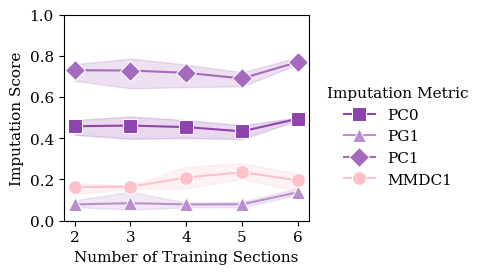

In [33]:
score_vs_num_train_sections_by_metric(
    df_long,
    save_dir=save_dir,
    width=4,
    height=3,
)

In [61]:
display(df_long)

,dataset,seed,model,split,epoch,num_train_sections,metric,value,mode
0,Skin (Human),0,SQUINT,3 Patches,19,2,PC0,0.4108,test
1,Skin (Human),1,SQUINT,3 Patches,19,2,PC0,0.3791,test
2,Skin (Human),2,SQUINT,3 Patches,18,2,PC0,0.3898,test
3,Skin (Human),0,SQUINT,3 Patches,19,2,PC1,0.7389,test
4,Skin (Human),1,SQUINT,3 Patches,19,2,PC1,0.6664,test
5,Skin (Human),2,SQUINT,3 Patches,18,2,PC1,0.6836,test
6,Skin (Human),0,SQUINT,3 Patches,19,2,PG1,0.2959,test
7,Skin (Human),1,SQUINT,3 Patches,19,2,PG1,0.2459,test
8,Skin (Human),2,SQUINT,3 Patches,18,2,PG1,0.2598,test
9,Skin (Human),0,SQUINT,3 Patches,19,2,MMDC1,0.1071,test
